### Customer Segmentation Analysis Using RFM and K-Means Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [2]:
df = pd.read_excel(r"Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 541909
Columns: 8


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
df_clean = df.copy()

In [9]:
df_clean = df_clean.dropna(subset=["CustomerID"])

print("Rows after removing missing CustomerID:", len(df_clean))

Rows after removing missing CustomerID: 406829


In [10]:
cancelled_invoices = df_clean[
    df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

print("Cancelled invoices:", len(cancelled_invoices))

Cancelled invoices: 8905


In [11]:
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

print("Rows after removing cancelled invoices:", len(df_clean))

Rows after removing cancelled invoices: 397924


In [12]:
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))

Rows after removing duplicates: 392732


In [13]:
print("Zero UnitPrice rows:", (df_clean["UnitPrice"] == 0).sum())

Zero UnitPrice rows: 40


In [14]:
df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("Final rows after cleaning:", len(df_clean))

Final rows after cleaning: 392692


In [15]:
# Transaction Amount Calculation
df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

In [16]:
df_clean[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [17]:
# RFM Analysis

analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [18]:
rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

In [19]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [20]:
## RFM Descriptive Statistics

rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [21]:
rfm[["Recency", "Frequency", "Monetary"]].describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


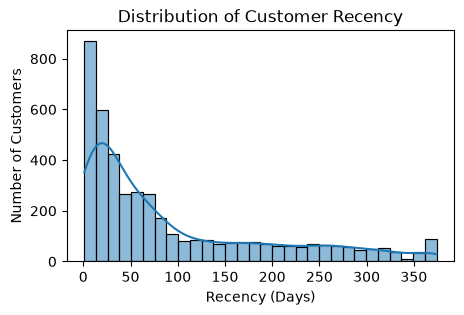

In [22]:
plt.figure(figsize=(5,3))

sns.histplot(rfm["Recency"], bins=30, kde=True)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

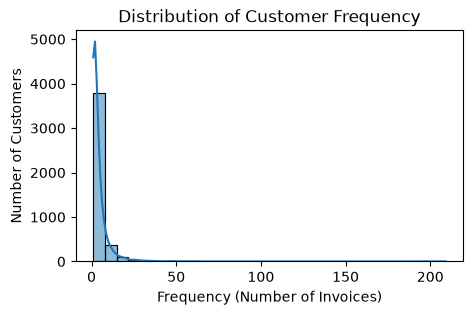

In [23]:
plt.figure(figsize=(5,3))

sns.histplot(rfm["Frequency"], bins=30, kde=True)

plt.title("Distribution of Customer Frequency")
plt.xlabel("Frequency (Number of Invoices)")
plt.ylabel("Number of Customers")

plt.show()

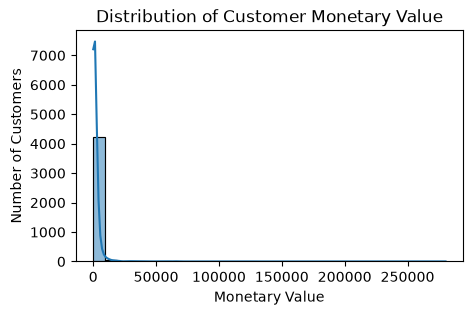

In [24]:
plt.figure(figsize=(5,3))

sns.histplot(rfm["Monetary"], bins=30, kde=True)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Monetary Value")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

rfm_features.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [26]:
scaler = StandardScaler()

In [27]:
rfm_scaled = scaler.fit_transform(rfm_features)

In [28]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


In [29]:
print("Means:")
print(rfm_scaled_df.mean())

print("\nStandard Deviations:")
print(rfm_scaled_df.std())

Means:
Recency      2.702618e-17
Frequency    1.801745e-17
Monetary     2.293130e-17
dtype: float64

Standard Deviations:
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64


In [30]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

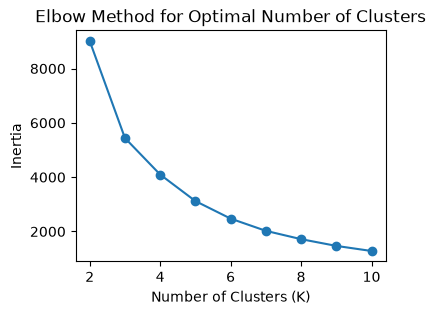

In [31]:
plt.figure(figsize=(4,3))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [32]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [33]:
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [34]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [35]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

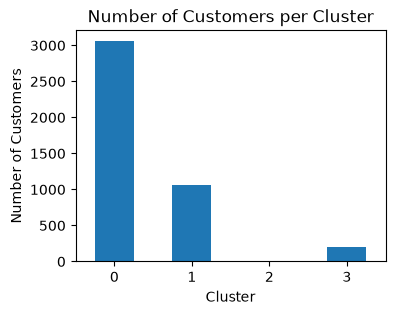

In [36]:
plt.figure(figsize=(4,3))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

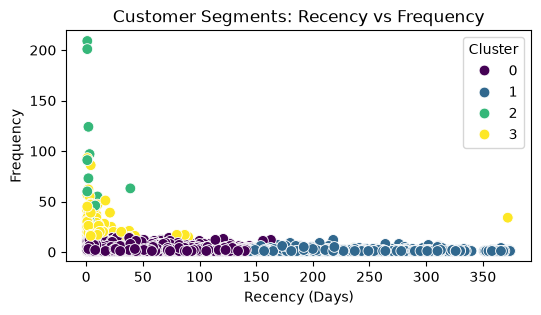

In [37]:
plt.figure(figsize=(6,3))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Frequency")
plt.legend(title="Cluster")

plt.show()

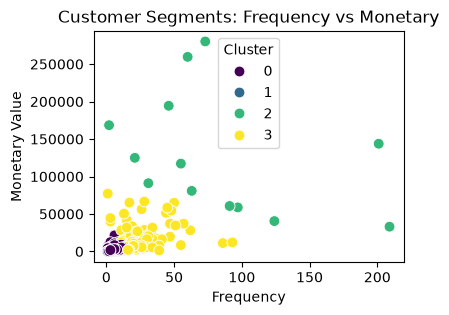

In [38]:
plt.figure(figsize=(4,3))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

In [39]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).reset_index()

cluster_profile

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,3054,43.702685,3.682711,1353.625312
1,1,1067,248.075914,1.552015,478.848773
2,2,13,7.384615,82.538462,127187.959231
3,3,204,15.500000,22.333333,12690.500392


In [40]:
cluster_profile[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
] = cluster_profile[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
].round(2)

cluster_profile

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,3054,43.70,3.68,1353.63
1,1,1067,248.08,1.55,478.85
2,2,13,7.38,82.54,127187.96
3,3,204,15.50,22.33,12690.50


In [41]:
segment_names = {
    0: "Regular Customers",
    1: "Inactive Low-Value Customers",
    2: "Very High-Value Customers",
    3: "High-Value Active Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

In [42]:
rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]].head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,High-Value Active Customers
1,12347.0,2,7,4310.00,0,Regular Customers
2,12348.0,75,4,1797.24,0,Regular Customers
3,12349.0,19,1,1757.55,0,Regular Customers
4,12350.0,310,1,334.40,1,Inactive Low-Value Customers


In [43]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).reset_index()

In [44]:
segment_summary[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
] = segment_summary[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
].round(2)

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,High-Value Active Customers,204,15.50,22.33,12690.50
1,Inactive Low-Value Customers,1067,248.08,1.55,478.85
2,Regular Customers,3054,43.70,3.68,1353.63
3,Very High-Value Customers,13,7.38,82.54,127187.96
